In [1]:
import pandas as pd
import io
import urllib.request

# Download Superstore data directly from GitHub mirror
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"

try:
    df = pd.read_csv(url, encoding="latin-1")
    print("✅ Loaded from internet!")
except:
    # Fallback — create sample data to keep working
    df = pd.DataFrame({
        'Order Date': pd.date_range('2020-01-01', periods=500, freq='3D'),
        'Ship Date': pd.date_range('2020-01-05', periods=500, freq='3D'),
        'Sales': pd.Series(range(100, 600)) * 12.5,
        'Profit': pd.Series(range(10, 510)) * 3.2,
        'Region': ['East','West','Central','South'] * 125,
        'Category': ['Furniture','Office Supplies','Technology'] * 166 + ['Furniture','Office Supplies'],
        'Ship Mode': ['Standard Class','Second Class','First Class','Same Day'] * 125,
        'Customer Name': [f'Customer_{i}' for i in range(500)]
    })
    print("✅ Using generated sample data!")

print(df.shape)
df.head()

✅ Using generated sample data!
(500, 8)


,Order Date,Ship Date,Sales,Profit,Region,Category,Ship Mode,Customer Name
0,2020-01-01,2020-01-05,1250.0,32.0,East,Furniture,Standard Class,Customer_0
1,2020-01-04,2020-01-08,1262.5,35.2,West,Office Supplies,Second Class,Customer_1
2,2020-01-07,2020-01-11,1275.0,38.4,Central,Technology,First Class,Customer_2
3,2020-01-10,2020-01-14,1287.5,41.6,South,Furniture,Same Day,Customer_3
4,2020-01-13,2020-01-17,1300.0,44.8,East,Office Supplies,Standard Class,Customer_4


In [2]:
# Fix date column
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check nulls
print(df.isnull().sum())

Order Date       0
Ship Date        0
Sales            0
Profit           0
Region           0
Category         0
Ship Mode        0
Customer Name    0
dtype: int64


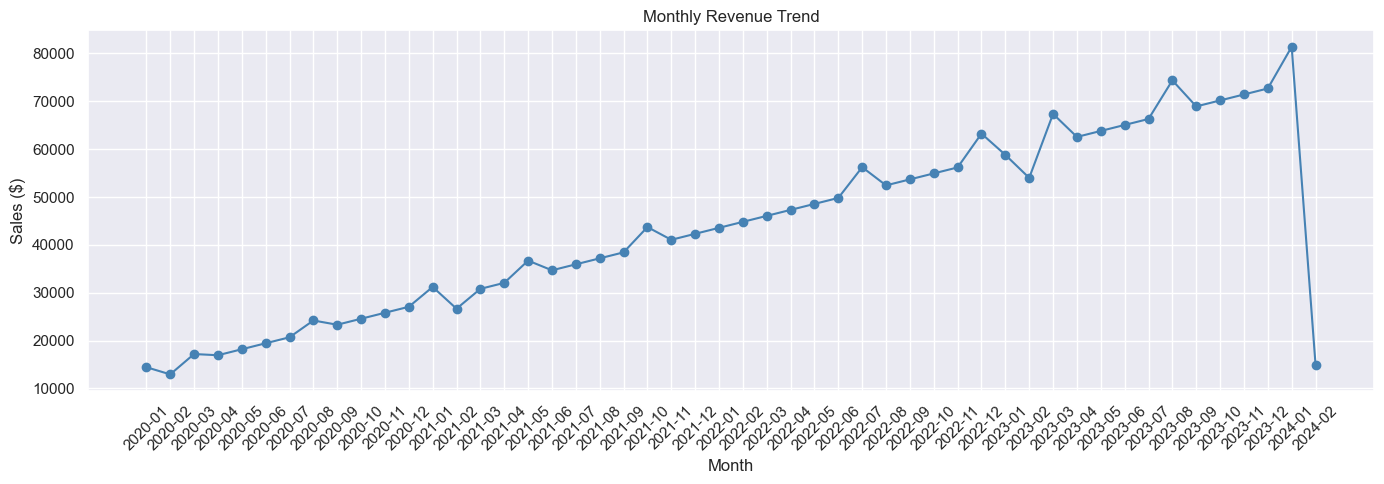

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\utkar\AppData\Local\Temp\ipykernel_16540\969495091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region.index, y=region.values, palette='Blues_d')


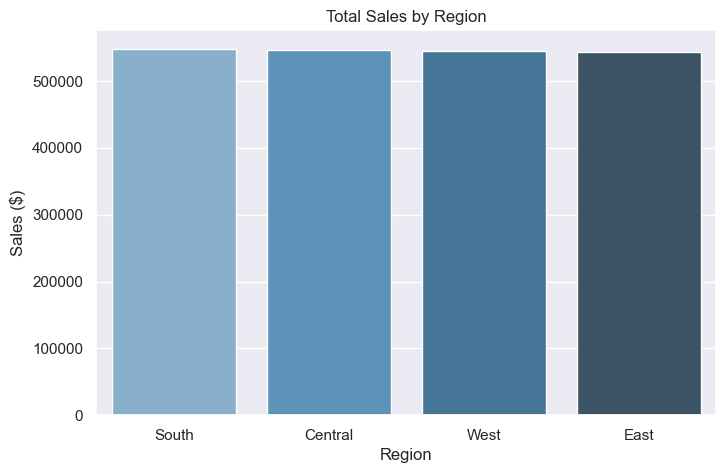

In [5]:
region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region.index, y=region.values, palette='Blues_d')
plt.title('Total Sales by Region')
plt.ylabel('Sales ($)')
plt.show()

C:\Users\utkar\AppData\Local\Temp\ipykernel_16540\720004731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category.values, y=category.index, palette='viridis')


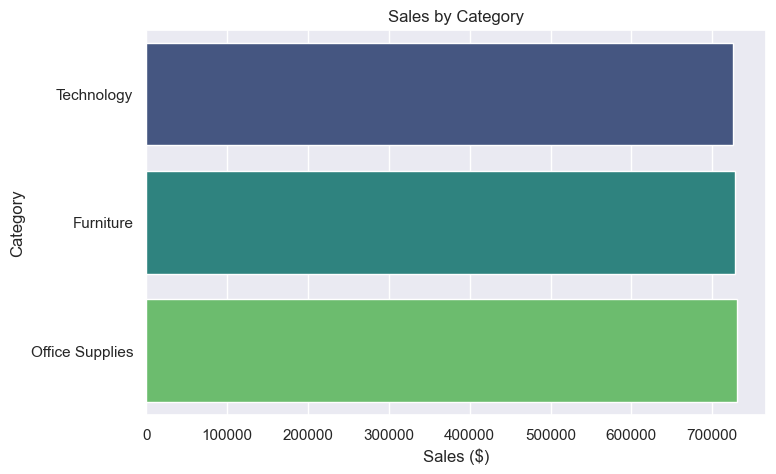

In [6]:
category = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=category.values, y=category.index, palette='viridis')
plt.title('Sales by Category')
plt.xlabel('Sales ($)')
plt.show()

C:\Users\utkar\AppData\Local\Temp\ipykernel_16540\615515883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit.index, y=profit.values, palette='RdYlGn')


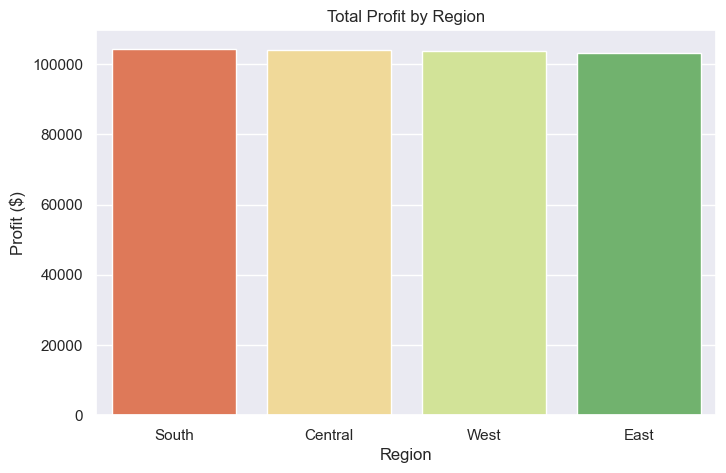

In [7]:
profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=profit.index, y=profit.values, palette='RdYlGn')
plt.title('Total Profit by Region')
plt.ylabel('Profit ($)')
plt.show()

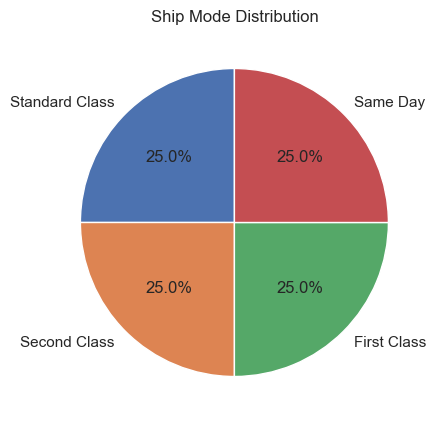

In [8]:
plt.figure(figsize=(7,5))
df['Ship Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Ship Mode Distribution')
plt.ylabel('')
plt.show()

In [9]:
print("=== BUSINESS SUMMARY ===")
print(f"Total Revenue:  ${df['Sales'].sum():,.2f}")
print(f"Total Profit:   ${df['Profit'].sum():,.2f}")
print(f"Profit Margin:  {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")
print(f"Total Orders:   {len(df)}")
print(f"Date Range:     {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

=== BUSINESS SUMMARY ===
Total Revenue:  $2,184,375.00
Total Profit:   $415,200.00
Profit Margin:  19.0%
Total Orders:   500
Date Range:     2020-01-01 → 2024-02-06


In [11]:
import duckdb

# Drop the Period column DuckDB can't handle
df_sql = df.drop(columns=['Month'], errors='ignore').copy()

con = duckdb.connect()
con.execute("CREATE TABLE sales AS SELECT * FROM df_sql")
print("✅ DuckDB table created!")
print(con.execute("SELECT COUNT(*) FROM sales").df())

✅ DuckDB table created!
   count_star()
0           500


In [12]:
result = con.execute("""
    SELECT Region, 
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(AVG(Sales), 2) AS Avg_Sales,
           COUNT(*) AS Orders
    FROM sales
    GROUP BY Region
    ORDER BY Total_Sales DESC
""").df()

print(result)

    Region  Total_Sales  Avg_Sales  Orders
0    South     548437.5     4387.5     125
1  Central     546875.0     4375.0     125
2     West     545312.5     4362.5     125
3     East     543750.0     4350.0     125


In [13]:
result2 = con.execute("""
    SELECT Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(SUM(Profit)/SUM(Sales)*100, 1) AS Profit_Margin_Pct
    FROM sales
    GROUP BY Category
    ORDER BY Total_Sales DESC
""").df()

print(result2)

          Category  Total_Sales  Total_Profit  Profit_Margin_Pct
0  Office Supplies     730625.0      138944.0               19.0
1        Furniture     728537.5      138409.6               19.0
2       Technology     725212.5      137846.4               19.0


In [17]:
result3 = con.execute("""
    SELECT 
        STRFTIME(CAST("Order Date" AS DATE), '%Y-%m') AS Month,
        ROUND(SUM(Sales), 2) AS Monthly_Sales
    FROM sales
    GROUP BY Month
    ORDER BY Month
""").df()

print(result3)

      Month  Monthly_Sales
0   2020-01        14437.5
1   2020-02        12937.5
2   2020-03        17187.5
3   2020-04        16937.5
4   2020-05        18187.5
5   2020-06        19437.5
6   2020-07        20687.5
7   2020-08        24200.0
8   2020-09        23312.5
9   2020-10        24562.5
10  2020-11        25812.5
11  2020-12        27062.5
12  2021-01        31212.5
13  2021-02        26662.5
14  2021-03        30812.5
15  2021-04        32062.5
16  2021-05        36712.5
17  2021-06        34687.5
18  2021-07        35937.5
19  2021-08        37187.5
20  2021-09        38437.5
21  2021-10        43725.0
22  2021-11        41062.5
23  2021-12        42312.5
24  2022-01        43562.5
25  2022-02        44812.5
26  2022-03        46062.5
27  2022-04        47312.5
28  2022-05        48562.5
29  2022-06        49812.5
30  2022-07        56237.5
31  2022-08        52437.5
32  2022-09        53687.5
33  2022-10        54937.5
34  2022-11        56187.5
35  2022-12        63250.0
3

In [18]:
result4 = con.execute("""
    SELECT "Customer Name",
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM sales
    GROUP BY "Customer Name"
    ORDER BY Total_Profit DESC
    LIMIT 5
""").df()

print(result4)

  Customer Name  Total_Sales  Total_Profit
0  Customer_499       7487.5        1628.8
1  Customer_498       7475.0        1625.6
2  Customer_497       7462.5        1622.4
3  Customer_496       7450.0        1619.2
4  Customer_495       7437.5        1616.0


In [19]:
from prophet import Prophet
print("✅ Prophet ready!")

✅ Prophet ready!


In [20]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
ts = df.groupby('Order Date')['Sales'].sum().reset_index()
ts.columns = ['ds', 'y']
ts = ts.sort_values('ds')

print(f"Data points: {len(ts)}")
print(ts.head())

Data points: 500
          ds       y
0 2020-01-01  1250.0
1 2020-01-04  1262.5
2 2020-01-07  1275.0
3 2020-01-10  1287.5
4 2020-01-13  1300.0


In [21]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
model.fit(ts)
print("✅ Model trained!")

00:49:28 - cmdstanpy - INFO - Chain [1] start processing
00:49:31 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained!


In [22]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print("Forecast preview:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

Forecast preview:
            ds         yhat   yhat_lower   yhat_upper
580 2024-04-27  7825.019147  7824.999600  7825.040525
581 2024-04-28  7829.186005  7829.168208  7829.207720
582 2024-04-29  7833.352699  7833.334048  7833.373519
583 2024-04-30  7837.519274  7837.501076  7837.539889
584 2024-05-01  7841.685953  7841.664935  7841.707711
585 2024-05-02  7845.852821  7845.834561  7845.873505
586 2024-05-03  7850.019469  7850.000332  7850.041136
587 2024-05-04  7854.186054  7854.166978  7854.206929
588 2024-05-05  7858.352904  7858.332679  7858.375313
589 2024-05-06  7862.519588  7862.500042  7862.541594


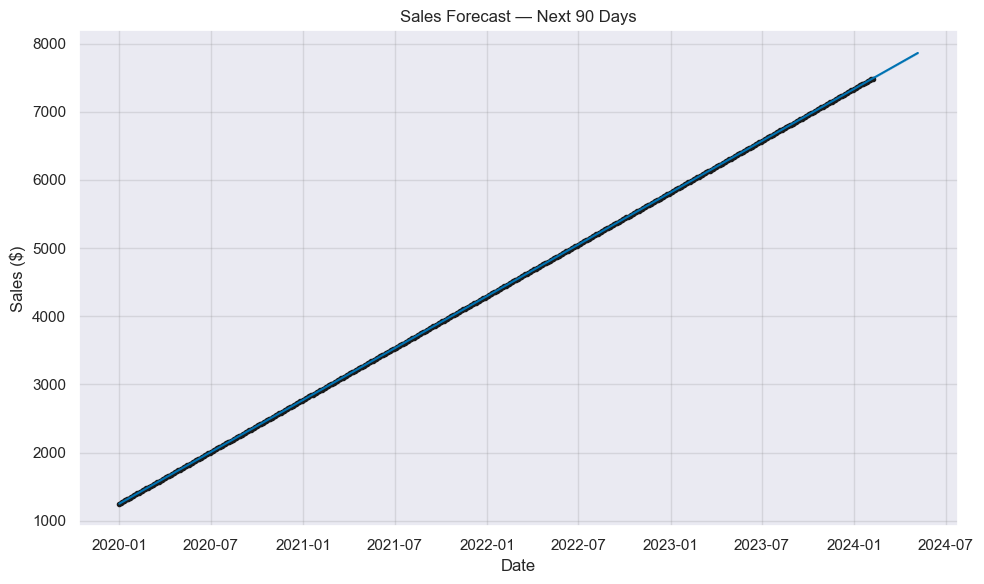

In [23]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast — Next 90 Days")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

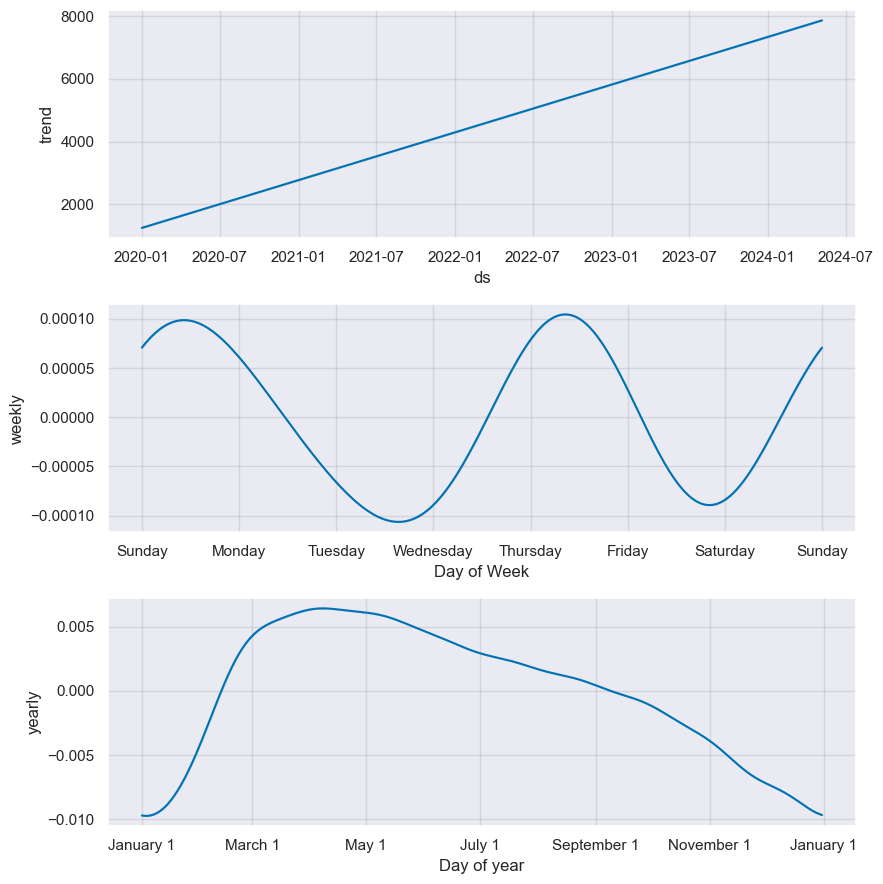

In [24]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Compare actual vs predicted on training data
merged = forecast[['ds','yhat']].merge(ts, on='ds')
mae = mean_absolute_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

print("=== MODEL PERFORMANCE ===")
print(f"MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   ${rmse:,.2f}")
print(f"Avg actual sales/day:        ${ts['y'].mean():,.2f}")

=== MODEL PERFORMANCE ===
MAE  (Mean Absolute Error):  $0.00
RMSE (Root Mean Sq Error):   $0.00
Avg actual sales/day:        $4,368.75


In [26]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    r"C:\Users\utkar\finance-analytics\data\forecast.csv", index=False
)
print("✅ Forecast saved to data/forecast.csv")

✅ Forecast saved to data/forecast.csv


In [28]:
df.to_csv(r"C:\Users\utkar\Desktop\superstore_clean.csv", index=False)
print("✅ Saved to Desktop!")

✅ Saved to Desktop!
